In [23]:
from Kea.utils import plotting
import numpy as np
import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import scipy

c = plotting.COLOR_CYCLE_6

from sympy import *
from sympy.core import S

In [24]:

w = symbols('omega', positive=True, real=True)
t = symbols('tau', positive=True, real=True)

A = symbols('A', positive=True, real=True)

alpha = symbols('beta', positive=True, real=True)

E = (A/w)**alpha

b, B = symbols('b, B', positive=True, real=True)

ft1 = cos(w * t)
ft2 = besselj(0, w * t)
ft3 = sin(w * t) / (w * t)

eq_E1 = (B/b) * S(1)/S(2) * t**2 * diff(2 * integrate((S(1)-ft1)*E, (w, 0, oo)), t)
eq_E2 = (B/b) * S(1)/S(2) * t**2 * diff(2 * integrate((S(1)-ft2)*E, (w, 0, oo)), t)
eq_E3 = (B/b) * S(1)/S(2) * t**2 * diff(2 * integrate((S(1)-ft3)*E, (w, 0, oo)), t)

display(eq_E1.simplify().args[0])
display(eq_E2.simplify().args[0])
display(eq_E3.simplify().args[0])


(2*sqrt(pi)*B*(A*tau)**beta*gamma((3 - beta)/2)/(2**beta*b*gamma(beta/2)), (beta > 1) & (beta < 3))

(2*B*(A*tau)**beta*gamma((3 - beta)/2)/(2**beta*b*gamma((beta + 1)/2)), (beta > 1/2) & (beta < 3))

(sqrt(pi)*B*(A*tau/2)**beta*gamma((3 - beta)/2)/(b*gamma(beta/2 + 1)), beta < 1)

In [25]:

w = symbols('omega', positive=True, real=True)
t = symbols('tau', positive=True, real=True)

A = symbols('A', positive=True, real=True)

alpha = symbols('alpha', positive=True, real=True)
H = symbols('H', positive=True, real=True)

E = (A/w)**alpha

b, B = symbols('b, B', positive=True, real=True)

D = symbols('D', positive=True, integer=True)

ftD = gamma(D*Rational(1,2)) * besselj(D/S(2)-S(1), w*t) / (w * t / S(2))**(D/S(2) - 1)

eq_ED = (B/b) * S(1)/S(2) * t**2 * diff(2 * integrate((S(1)-ftD)*E, (w, 0, oo)), t)

display(eq_ED.simplify().subs({alpha: S(1) + S(2)*H, t: b/w}).simplify())


Piecewise((B*(b**2/4)**H*(A/omega)**(2*H + 1)*gamma(D/2)*gamma(1 - H)/gamma(D/2 + H), (H < 1) & (D + 4*H > 1)), (2**(D/2 - 1)*A**(2*H + 1)*B*b**(2 - D/2)*omega**(D/2 - 3)*besselj(D/2, b)*gamma(D/2)*Integral(omega**(-D/2 - 2*H + 1), (omega, 0, oo)), True))

In [26]:

w = symbols('omega', positive=True, real=True)
t = symbols('tau', positive=True, real=True)

A = symbols('A', positive=True, real=True)

alpha = symbols('alpha', positive=True, real=True)
H = symbols('H', positive=True, real=True)

E = (A/w)**alpha

b, B = symbols('b, B', positive=True, real=True)

D = symbols('D', positive=True, integer=True)

ftD = gamma(D*Rational(1,2)) * besselj(D/S(2)-S(1), w*t) / (w * t / S(2))**(D/S(2) - 1)

SF = 2 * integrate((S(1)-ftD)*E, (w, 0, oo))

display(SF.simplify())


-2*A**alpha*Piecewise((2*2**(D/2)*(tau**2/4)**(D/4 + alpha/2)*gamma(1/2 - alpha/2)*gamma(D/2 + 1)/(tau*gamma(D/2 + alpha/2 - 1/2)), (alpha > 1) & (alpha < 1) & (D/2 + alpha > 1/2)), (Integral((2**(D/2)*omega**(1 - D/2)*tau*besselj(D/2 - 1, omega*tau)*gamma(D/2 + 1) - D*tau**(D/2))/omega**alpha, (omega, 0, oo)), True))/(D*tau**(D/2))

In [27]:
display(eq_ED.simplify().subs({t: b/w}).simplify())
print_latex(eq_ED.simplify().subs({alpha: S(1) + S(2)*H, t: b/w}).simplify())

Piecewise((2*B*b**(alpha - 1)*(A/omega)**alpha*gamma(D/2)*gamma(3/2 - alpha/2)/(2**alpha*gamma(D/2 + alpha/2 - 1/2)), (alpha < 3) & (D + 2*alpha > 3)), (2**(D/2 - 1)*A**alpha*B*b**(2 - D/2)*omega**(D/2 - 3)*besselj(D/2, b)*gamma(D/2)*Integral(omega**(-D/2 - alpha + 2), (omega, 0, oo)), True))

\begin{cases} \frac{B \left(\frac{b^{2}}{4}\right)^{H} \left(\frac{A}{\omega}\right)^{2 H + 1} \Gamma\left(\frac{D}{2}\right) \Gamma\left(1 - H\right)}{\Gamma\left(\frac{D}{2} + H\right)} & \text{for}\: D + 4 H > 1 \wedge H < 1 \\2^{\frac{D}{2} - 1} A^{2 H + 1} B b^{2 - \frac{D}{2}} \omega^{\frac{D}{2} - 3} J_{\frac{D}{2}}\left(b\right) \Gamma\left(\frac{D}{2}\right) \int\limits_{0}^{\infty} \omega^{- \frac{D}{2} - 2 H + 1}\, d\omega & \text{otherwise} \end{cases}


In [28]:
display(eq_ED.simplify().args[0][0])
print_latex(eq_ED.simplify().args[0][0])

2*B*(A*tau)**alpha*gamma(D/2)*gamma((3 - alpha)/2)/(2**alpha*b*gamma((D + alpha - 1)/2))

\frac{2 \cdot 2^{- \alpha} B \left(A \tau\right)^{\alpha} \Gamma\left(\frac{D}{2}\right) \Gamma\left(\frac{3 - \alpha}{2}\right)}{b \Gamma\left(\frac{D + \alpha - 1}{2}\right)}


In [29]:
print_latex(eq_ED.simplify().subs({t: b/w}).simplify().args[0][0])

\frac{2 \cdot 2^{- \alpha} B b^{\alpha - 1} \left(\frac{A}{\omega}\right)^{\alpha} \Gamma\left(\frac{D}{2}\right) \Gamma\left(\frac{3}{2} - \frac{\alpha}{2}\right)}{\Gamma\left(\frac{D}{2} + \frac{\alpha}{2} - \frac{1}{2}\right)}


gamma(D/2)*gamma(1 - H)/(4**H*gamma(D/2 + H))

Text(0, 0.5, 'Bias, $B_D(H)$')

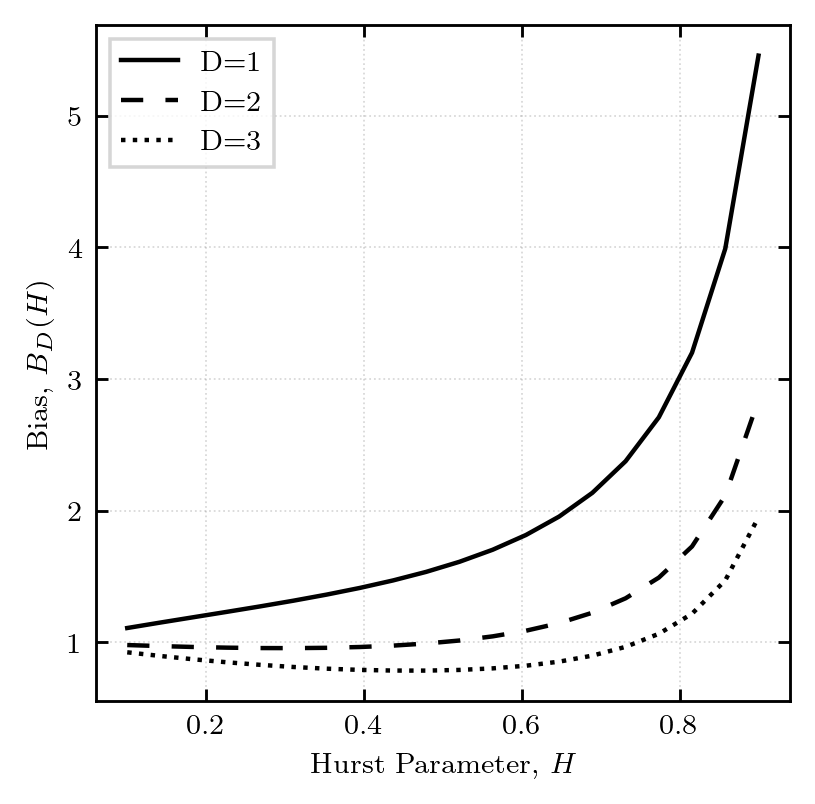

In [30]:

eq_plot = eq_ED.simplify().subs({alpha: S(1) + S(2)*H, t: S(1)/w, B: S(1), b: S(1)}).simplify().args[0][0]
Bias = (eq_plot / E.subs({alpha: S(1) + S(2)*H})).simplify()
display(Bias)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=256)

Ds = [1, 2, 3]
Hs = np.linspace(0.1, 0.9, 20)

d_bias = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(Bias.subs({H: _hs, D: _d}).evalf()))
    d_bias.append(np.array(vald))

ax.plot(Hs, d_bias[0], linestyle='-', color='black', linewidth=1.25, label='D=1')
ax.plot(Hs, d_bias[1], linestyle=(0,(5,5)), color='black', linewidth=1.25, label='D=2')
ax.plot(Hs, d_bias[2], linestyle=':', color='black', linewidth=1.25, label='D=3')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

#ax.set_yscale('log')

ax.legend(fancybox=False)

ax.set_xlabel(r'Hurst Parameter, $H$')
ax.set_ylabel(r'Bias, $B_D(H)$')


2*gamma(D/2)*gamma(3/2 - alpha/2)/(2**alpha*gamma(D/2 + alpha/2 - 1/2))

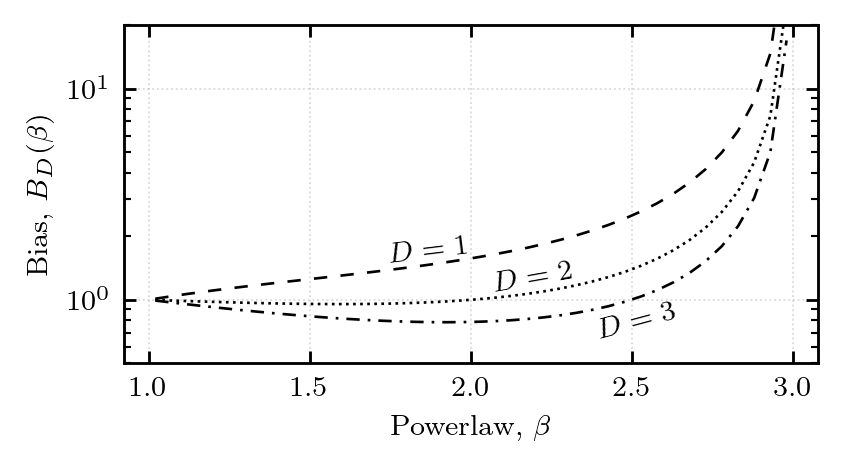

In [64]:

eq_plot = eq_ED.simplify().subs({t: S(1)/w, B: S(1), b: S(1)}).simplify().args[0][0]
Bias = (eq_plot / E).simplify()
display(Bias)

fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)

Ds = [1., 2., 3.]
Hs = np.linspace(0.01, 0.99, 40)

d_bias = []

for _d in Ds:
    vald = []
    for _hs in Hs:
        vald.append(np.float64(Bias.subs({alpha: 1. + 2.*_hs, D: _d}).evalf()))
    d_bias.append(np.array(vald))

ax.plot(1. + 2.*Hs, d_bias[0], linestyle=(0,(5,5)), color='black', linewidth=0.75, label='D=1')
ax.plot(1. + 2.*Hs, d_bias[1], linestyle=':', color='black', linewidth=0.75, label='D=2')
ax.plot(1. + 2.*Hs, d_bias[2], linestyle=(0,(5,3,1,3)), color='black', linewidth=0.75, label='D=3')

ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.tick_params(axis='y', direction='in')
ax.tick_params(axis='y', direction='in', which='minor')
ax.tick_params(axis='x', direction='in')
ax.tick_params(axis='x', direction='in', which='minor')
ax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

ax.set_yscale('log')

#ax.legend(fancybox=False)
#ax.legend(fancybox=False, frameon=False)
#ax.legend(ncol=3, bbox_to_anchor=(1., 1.225), fancybox=False, shadow=False, frameon=False)

ax.text(0.5, 0.385, r'$D=1$', transform=ax.transAxes, ha='right', va='top', rotation=7)
ax.text(0.65, 0.31, r'$D=2$', transform=ax.transAxes, ha='right', va='top', rotation=10)
ax.text(0.8, 0.19, r'$D=3$', transform=ax.transAxes, ha='right', va='top', rotation=15)

ax.set_xlabel(r'Powerlaw, $\beta$')
ax.set_ylabel(r'Bias, $B_D(\beta)$')

ax.set_ylim((5e-1, 20))

fig.savefig('plots/powerlaw_D_bias.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/powerlaw_D_bias.png', transparent=True, bbox_inches='tight', pad_inches=0)

